## Assignment: Pandas Groupby with Hurricane Data

In [30]:
import pandas as pd
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [31]:
len(df)

716165

##### This dataset has 716,165 rows.

In [32]:
(df['BASIN'] == 'NA').sum()

126392

##### There are 126,392 North Atlantic hurricanes in this dataset.

#### 1) Get the unique values of the BASIN, SUBBASIN, and NATURE columns

In [33]:
df['BASIN'].unique()

array(['NI', 'SI', 'NA', 'EP', 'WP', 'SP', 'SA'], dtype=object)

In [34]:
df['SUBBASIN'].unique()

array(['BB', 'AS', 'MM', 'GM', 'NA', 'CS', 'WA', 'EA', 'CP'], dtype=object)

In [35]:
df['NATURE'].unique()

array(['NR', 'TS', 'ET', 'SS', 'MX', 'DS'], dtype=object)

#### 2) Rename the WMO_WIND and WMO_PRES columns to WIND and PRES

In [36]:
df = df.rename(columns={'WMO_WIND': 'WIND', 'WMO_PRES': 'PRES'})

In [37]:
df.columns

Index(['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME',
       'NATURE', 'LAT', 'LON', 'WIND', 'PRES'],
      dtype='object')

#### 3) Get the 10 largest rows in the dataset by WIND

In [38]:
df.nlargest(10, 'WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


#### 4) Group the data on SID and get the 10 largest hurricanes by WIND

In [39]:
df.groupby('SID').WIND.max().nlargest(10)

SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: WIND, dtype: float64

#### 5) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes

<Axes: xlabel='NAME'>

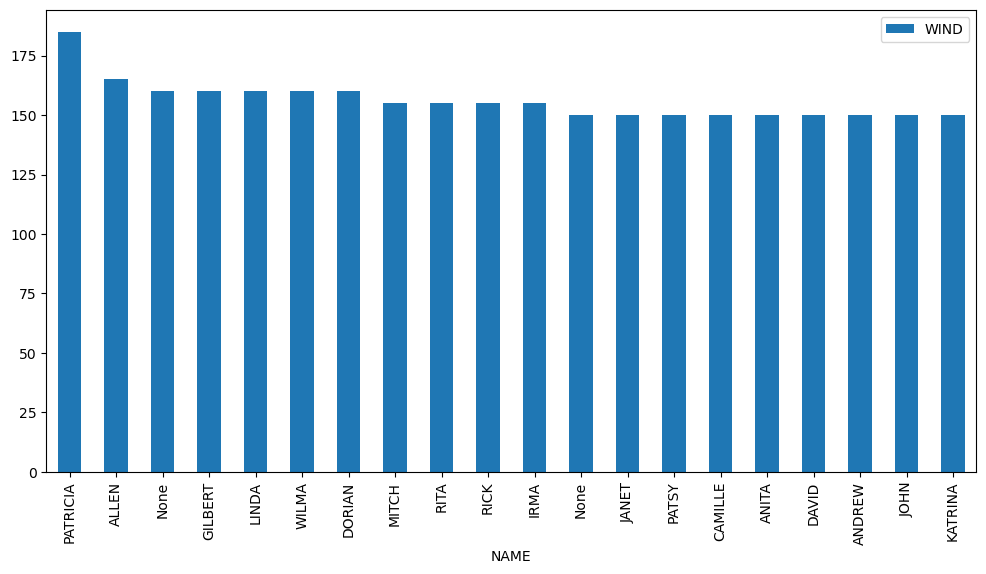

In [40]:
gb = df.groupby('SID')
top20 = gb.aggregate({'NAME': 'first', 'WIND': 'max'}).nlargest(20, 'WIND')
top20.plot(kind='bar', x='NAME', y='WIND',figsize=(12,6))

#### 6) Plot the count of all datapoints by Basin

<Axes: xlabel='BASIN'>

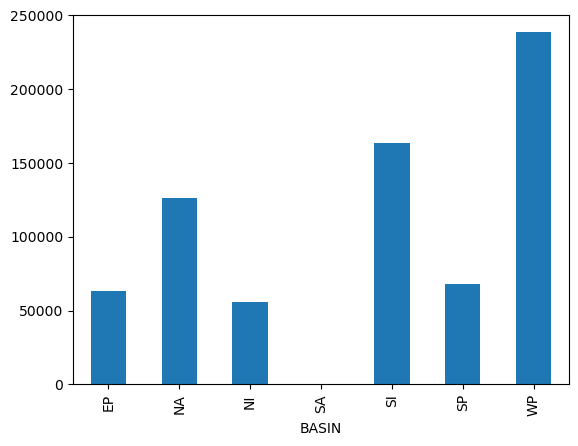

In [41]:
df.groupby('BASIN').SID.count().plot(kind='bar')

#### 7) Plot the count of unique hurricanes by Basin

<Axes: xlabel='BASIN'>

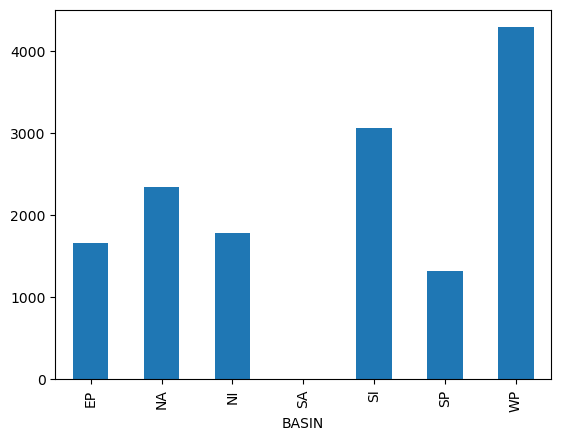

In [42]:
df.groupby('BASIN').SID.nunique().plot(kind='bar')

####

#### 8) Make a hexbin of the location of datapoints in Latitude and Longitude

<Axes: xlabel='LON', ylabel='LAT'>

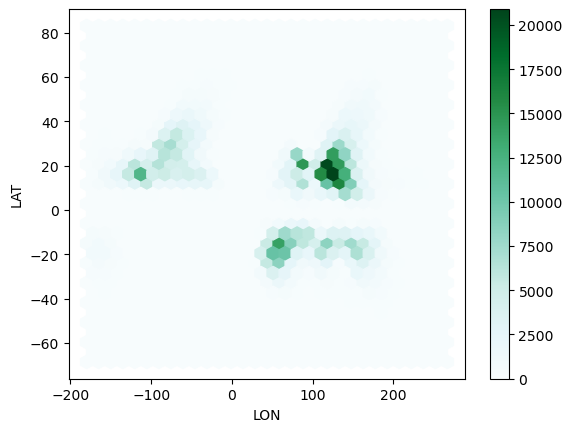

In [43]:
df.plot.hexbin(x='LON', y='LAT', gridsize=30)

#### 9) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot

In [44]:
df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)].SID.unique()

array(['2005236N23285'], dtype=object)

In [45]:
sid = df[(df['NAME'] == 'KATRINA') & (df['SEASON'] == 2005)].SID.unique()[0]

In [46]:
katrina = df[df['SID'] == sid]

<Axes: xlabel='LON', ylabel='LAT'>

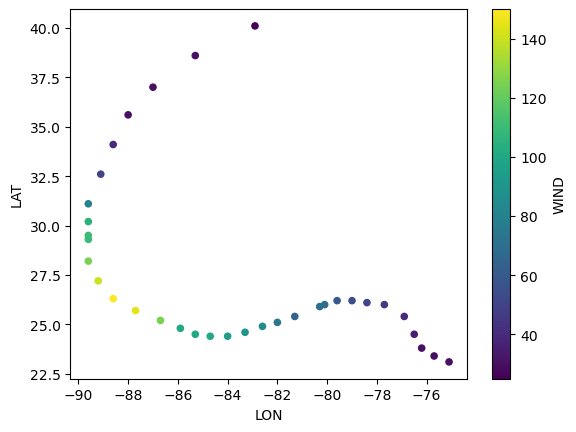

In [47]:
katrina.plot.scatter(x='LON', y='LAT', c='WIND')

#### 10) Make time the index on your dataframe

In [ ]:
df = df.set_index('ISO_TIME')

In [51]:
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.9000,80.3000,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8709,79.8265,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8431,79.3524,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8188,78.8772,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,NaN,NR,10.8000,78.4000,NaN,NaN


#### 11) Plot the count of all datapoints per year as a timeseries

<Axes: xlabel='ISO_TIME'>

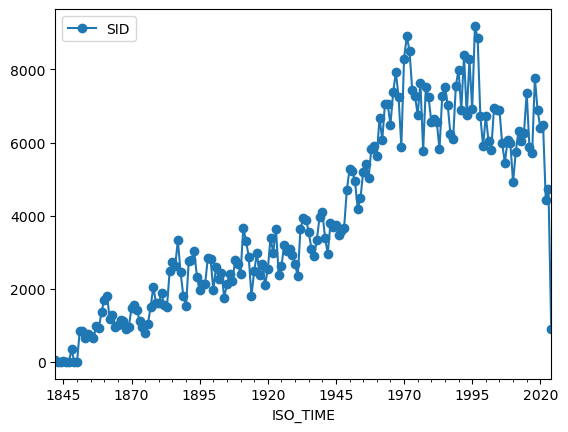

In [54]:
df.resample('YE').count().plot(y='SID', marker='o')

##### Years in the late 1960s to early 1970s and again in the mid-1990s stand out as unusually high. The earliest years in the record and the final year also appear unusually low, likely because the record is incomplete there.